In [ ]:
!python3 src/preprocessing/to-silver/add_noise.py --dataset ravdess --snr 30.0 --output-dir data/silver/chunked_noisy30
!python3 src/preprocessing/to-silver/add_noise.py --dataset savee --snr 30.0 --output-dir data/silver/chunked_noisy30

!python3 src/preprocessing/to-gold/01_extract_metadata.py --ravdess --silver-dir data/silver/chunked_noisy30 --gold-dir data/gold_noisy30_ravdess
!python3 src/preprocessing/to-gold/02_extract_acoustic_features.py --ravdess --metadata-path data/gold_noisy30_ravdess/basic_features/metadata.parquet --gold-dir data/gold_noisy30_ravdess
!python3 src/preprocessing/to-gold/05_extract_hubert_features.py --ravdess --metadata-path data/gold_noisy30_ravdess/basic_features/metadata.parquet --gold-dir data/gold_noisy30_ravdess
!python3 src/preprocessing/to-gold/06_extract_mel_spectrograms.py --ravdess --metadata-path data/gold_noisy30_ravdess/basic_features/metadata.parquet --gold-dir data/gold_noisy30_ravdess

!python3 src/preprocessing/to-gold/01_extract_metadata.py --savee --silver-dir data/silver/chunked_noisy30 --gold-dir data/gold_noisy30_savee
!python3 src/preprocessing/to-gold/02_extract_acoustic_features.py --savee --metadata-path data/gold_noisy30_savee/basic_features/metadata.parquet --gold-dir data/gold_noisy30_savee
!python3 src/preprocessing/to-gold/05_extract_hubert_features.py --savee --metadata-path data/gold_noisy30_savee/basic_features/metadata.parquet --gold-dir data/gold_noisy30_savee
!python3 src/preprocessing/to-gold/06_extract_mel_spectrograms.py --savee --metadata-path data/gold_noisy30_savee/basic_features/metadata.parquet --gold-dir data/gold_noisy30_savee


Додавання шуму (SNR=30.0dB) до 1056 файлів датасету ravdess...
100%|██████████████████████████████████████| 1056/1056 [00:07<00:00, 134.19it/s]
Додавання шуму (SNR=30.0dB) до 981 файлів датасету savee...
Збір метаданих RAVDESS: 100%|█████████████| 1056/1056 [00:00<00:00, 6207.96it/s]

Створення DataFrame та збереження у Parquet...
Готово! Успішно збережено 1056 рядків (метаданих чанків).
Файл знаходиться тут: data/gold_noisy30_ravdess/basic_features/metadata.parquet
Завантаження метаданих...
До обробки підготовлено 1056 аудіо-чанків.
Обчислення акустичних ознак: 100%|██████████| 1056/1056 [00:55<00:00, 19.16it/s]

Об'єднання метаданих з ознаками...
Готово! Успішно збережено 1056 рядків з 103 колонками.
Файл знаходиться тут: data/gold_noisy30_ravdess/features.parquet
Завантаження метаданих...
До обробки підготовлено 1056 аудіо-чанків.
Завантаження моделі facebook/hubert-base-ls960 на cuda...
Вилучення HuBERT ознак: 100%|███████████████| 1056/1056 [00:12<00:00, 83.56it/s]

Об'єднання мет

In [ ]:

!python3 src/models/evaluate_cross_corpus.py --model-type crnn --model-path "temp/CRNN_Combined_best_model.pth" --base-features "data/gold_noisy30_ravdess/features.parquet,data/gold_noisy30_savee/features.parquet" --run-name "CRNN_Combined_Noisy30" --hubert-features
!python3 src/models/evaluate_cross_corpus.py --model-type hubert --model-path "temp/HuBERT_Combined_best_model.pth" --base-features "data/gold_noisy30_ravdess/features.parquet,data/gold_noisy30_savee/features.parquet" --run-name "HuBERT_Combined_Noisy30"

Оцінка моделі crnn на пристрої: cuda
Завантаження даних з data/gold_noisy30_ravdess/features.parquet...
  Додавання ознак HuBERT...
  Додавання пре-обчислених Mel-спектрограм...
Завантаження даних з data/gold_noisy30_savee/features.parquet...
  Додавання ознак HuBERT...
  Додавання пре-обчислених Mel-спектрограм...
Об'єднаний датасет готовий! Розмірність (рядки, колонки): (2037, 12903)
Inference CRNN: 100%|███████████████████████████| 32/32 [00:00<00:00, 82.73it/s]

--- Результати Cross-Corpus оцінки (CRNN_Combined_Noisy30) ---
              precision    recall  f1-score   support

         ang       0.81      0.72      0.76       311
         fea       0.70      0.70      0.70       330
         hap       0.74      0.73      0.74       323
         neu       0.77      0.75      0.76       383
         sad       0.61      0.68      0.64       369
         sur       0.69      0.70      0.69       321

    accuracy                           0.71      2037
   macro avg       0.72      0.7

## Результати падіння точності від шуму 30 дБ: CRNN_Combined_Noisy30

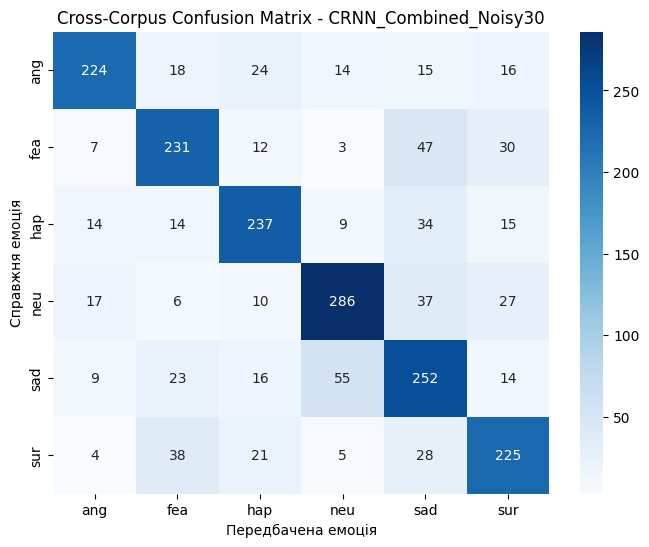

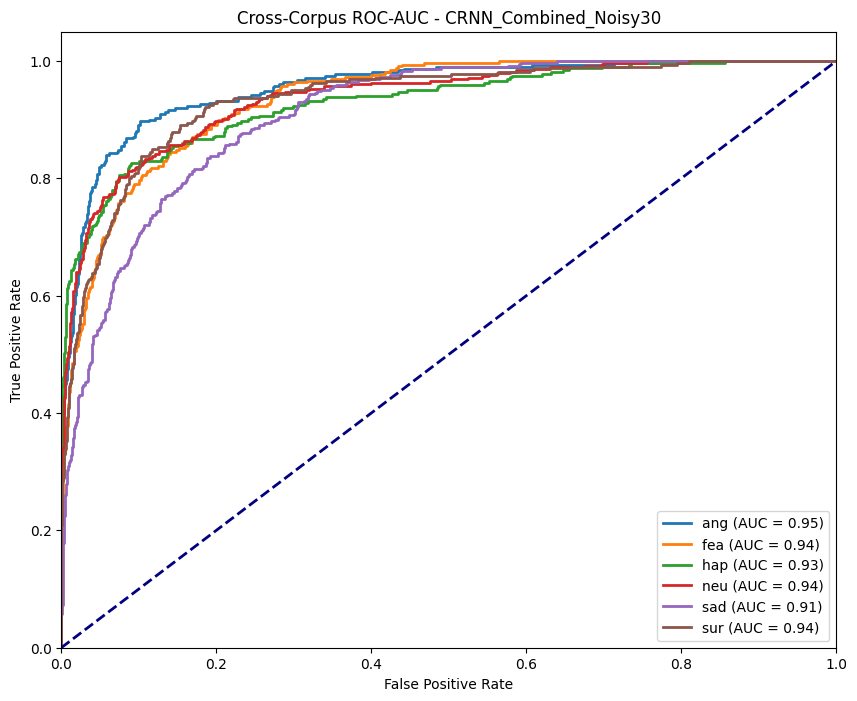

---

## Результати падіння точності від шуму 30 дБ: HuBERT_Combined_Noisy30

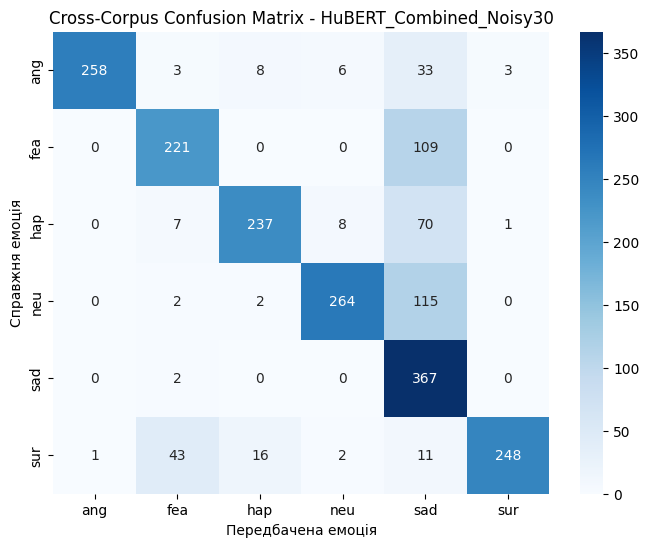

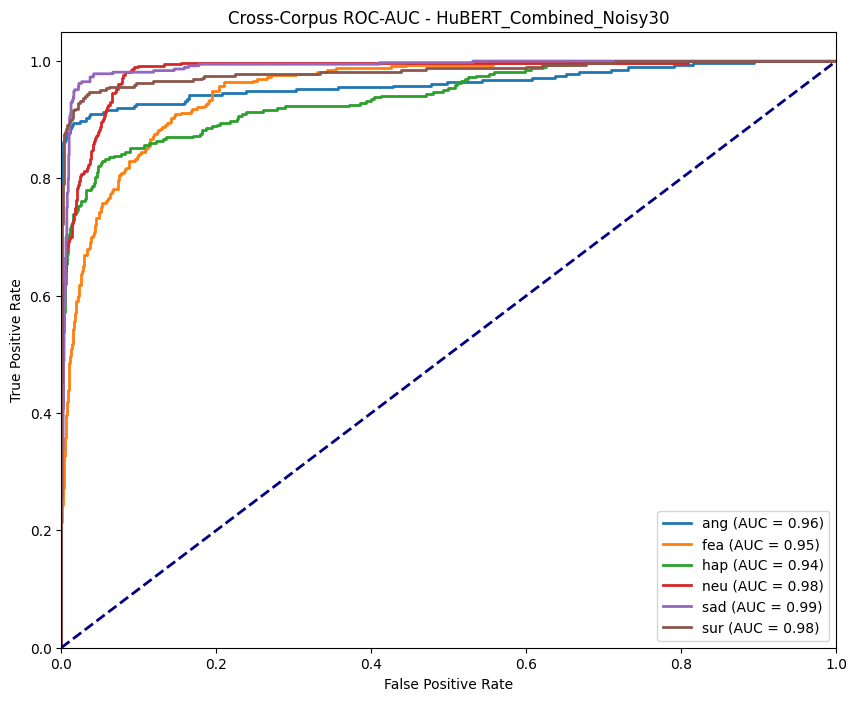

---

In [10]:
from IPython.display import Image, display, Markdown
import os

run_names = ["CRNN_Combined_Noisy30", "HuBERT_Combined_Noisy30"]

for run in run_names:
    if os.path.exists(f"temp/CrossCorpus_{run}_cm.png"):
        display(Markdown(f"## Результати падіння точності від шуму 30 дБ: {run}"))
        display(Image(filename=f"temp/CrossCorpus_{run}_cm.png"))
        display(Image(filename=f"temp/CrossCorpus_{run}_roc.png"))
        display(Markdown("---"))